In [ ]:
!pip install fasttext
!pip install wordfreq

In [2]:
# ! wget https://dl.fbaipublicfiles.com/fasttext/supervised-models/lid.176.bin

In [3]:
import pandas as pd
import numpy as np
import re
from collections import Counter
import fasttext

df = pd.read_parquet("hf://datasets/gentaiscool/codemixqa/data/test-00000-of-00001.parquet")

/home/mhira/miniconda3/envs/rag_clean/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
df.head(10)

,id,original_index,problem,answer,topic,answer_type,multi_step,requires_reasoning,urls,method,language
0,2174-grammarforce_source-Bengali,2174,Which baseball field-এ Central Illinois Colleg...,Lloyd Hopkins Field,Sports,Place,False,False,https://www.altonbaseball.com/custom_pages/982...,grammarforce_source,Bengali
1,2429-grammarforce_target-Urdu,2429,Tivoli Gardens میں Demon کے لیے جگہ بنانے کو ک...,The Snake,Other,Other,False,False,https://sophiessuitcase.com/a-guide-to-tivoli-...,grammarforce_target,Urdu
2,3532-grammarforce_source-Hindi,3532,1898 में New York के state entomologist की 14t...,Byturus tomentosus,Science and technology,Other,True,False,https://nysl.ptfs.com/aw-server/rest/product/p...,grammarforce_source,Hindi
3,1452-selective-Italian,1452,After chi was Bullard Mountain named in the Bo...,Benjamin Bullard,Geography,Person,False,False,https://en.wikipedia.org/wiki/Bullard_Mountain...,selective,Italian
4,4184-force-Japanese,4184,What four 健康組織 wrote to President ジョン・F・ケネディ c...,"American Cancer Society, the American Public H...",History,Other,False,False,https://www.ajmc.com/view/surgeon-generals-smo...,random,Japanese
5,394-force-Japanese,394,Which チーム won the コッパ・イタリア Serie C in the 1981...,Vicenza.,Sports,Other,False,False,https://en.wikipedia.org/wiki/Coppa_Italia_Ser...,random,Japanese
6,2313-selective-Hindi,2313,Italian baritone Antonio Scotti (1866-1936) ke...,1213 (acceptable range: anything between 1199 ...,Music,Number,False,True,https://medicine-opera.com/2019/05/the-mets-ho...,selective,Hindi
7,3092-grammarforce_target-Urdu,3092,"2000 میں St. John's Church, Gateshead Fell میں...","St Aidan's Church, Blackhill, Consett",Music,Place,False,False,https://en.wikipedia.org/wiki/St_John%27s_Chur...,grammarforce_target,Urdu
8,1592-grammarforce_target-Bengali,1592,কোন campus-এর নাম যেখানে Princess Shruti Rajya...,Padma Kanya Campus,Other,Place,False,False,https://ktmonlinekhabar.blogspot.com/2014/07/p...,grammarforce_target,Bengali
9,4070-selective-Hindi,4070,Kaunsi former First Lady ne 1977 se 1978 tak M...,Jackie Kennedy,Politics,Person,True,True,https://nz.news.yahoo.com/history-behind-met-g...,selective,Hindi


In [ ]:
hindi_sentences = df[df["language"] == "Hindi"]["problem"].tolist()
hindi_transliterated_sentences = df[df["language"] == "Hindi transliterate"]["problem"].tolist()

In [17]:
hindi_sentences[:5]

['1898 में New York के state entomologist की 14th report के अनुसार, Miss Ormerod ने अपनी 1893 की 15th report में England में raspberries को होने वाली गंभीर और व्यापक injuries किस insect से record की थीं? scientific name use करें.',
 'Italian baritone Antonio Scotti (1866-1936) ke Metropolitan Opera House mein 1899 aur 1933 ke beech total kitni performances hui thi?',
 'Kaunsi former First Lady ne 1977 se 1978 tak Met Gala ki co-chair ke roop mein serve kiya?',
 'Metropolitan Museum of Art ने Hendrick Goltzius के "Farnese Hercules" के लिए जो accession number दिया है, वह क्या है?',
 'Heisei के Ninja के नाम से जाने जाने वाले Japanese criminal का असली नाम क्या है?']

In [18]:
hindi_transliterated_sentences[:5]

['How much paisa, euros mein, was the surgeon jimmedaar thaharaaya gaya for Stella Obasanjo ki maut and ordered to pay her bete ko?',
 'Iceland ke former Prime Minister ka naam kya hai jo 1971 tak cabin crew member ke roop mein kaam karte the?',
 'Mehbooba Mufti Sayed ne 2019 lok sabha elections mein kiske against contest kiya aur haar gai?',
 'In which year mein Melbourne ka Monash Gallery of Art (MGA) ne rebrand kiya aur Museum of Australian Photography (MAPh) ban gaya?',
 'Who ne request kiya ki Federal Aviation Administration (FAA) Deepwater Horizon ke operations areas ke over 900 sq mi (2,300 km2) ka temporary flight restriction zone implement kare?']

In [ ]:
# for sentence in hindi_transliterated_sentences[:5]:
#     if "Italian" in sentence:
#         print(sentence)

In [ ]:
df["language"].value_counts()

language
Bengali                  4000
Urdu                     4000
Hindi                    4000
Italian                  4000
Japanese                 4000
Marathi                  4000
Spanish                  4000
Indonesian               4000
Korean                   4000
Simplified Chinese       4000
French                   4000
Toba Batak               4000
Bengali transliterate    4000
Hindi transliterate      4000
Marathi transliterate    4000
Urdu transliterate       4000
Name: count, dtype: int64

In [ ]:
df["method"].value_counts()

method
grammarforce_source    16000
grammarforce_target    16000
selective              16000
random                 16000
Name: count, dtype: int64

In [ ]:
df["multi_step"].value_counts()

multi_step
False    59328
True      4672
Name: count, dtype: int64

In [ ]:
model = fasttext.load_model("lid.176.bin")

def detect_lang(token):
    label, prob = model.predict(token)
    return label[0].replace("__label__", "")

In [ ]:
import re
from wordfreq import zipf_frequency
from collections import defaultdict

def tokenize(text):
    return re.findall(r"\b\w+\b", str(text))

def is_english_word(token):
    # threshold 3.0 filters rare noise
    return zipf_frequency(token.lower(), "en") > 3.0

# def calculate_code_switch_ratios(df):
#     language_ratios = defaultdict(list)

#     for _, row in df.iterrows():
#         text = row["problem"]
#         lang = row["language"]
        
#         tokens = tokenize(text)
#         if not tokens:
#             continue
        
#         english_count = sum(is_english_word(t) for t in tokens)
#         english_ratio = english_count / len(tokens)
#         x_ratio = 1 - english_ratio
        
#         language_ratios[lang].append(x_ratio)

#     # Average ratio per language
#     avg_ratios = {
#         lang: sum(vals) / len(vals)
#         for lang, vals in language_ratios.items()
#     }

#     return avg_ratios

In [ ]:
# ratios = calculate_code_switch_ratios(df)

# for lang, ratio in sorted(ratios.items(), key=lambda x: x[1]):
#     print(f"{lang}: {ratio:.3f}")

In [ ]:
def compute_row_ratios(row):
    tokens = tokenize(row["problem"])
    if not tokens:
        return 0.0
    
    english_count = sum(is_english_word(t) for t in tokens)
    return 1 - (english_count / len(tokens))  # X ratio

df["x_ratio"] = df.apply(compute_row_ratios, axis=1)

In [ ]:
df.groupby("language")["x_ratio"].mean()

language
Bengali                  0.643017
Bengali transliterate    0.360326
French                   0.314149
Hindi                    0.475727
Hindi transliterate      0.287608
Indonesian               0.457481
Italian                  0.356322
Japanese                 0.537409
Korean                   0.652852
Marathi                  0.677816
Marathi transliterate    0.468046
Simplified Chinese       0.466868
Spanish                  0.355263
Toba Batak               0.361607
Urdu                     0.554792
Urdu transliterate       0.308332
Name: x_ratio, dtype: float64

In [ ]:
bins = [0, .2, .4, .6, .8, 1]
df["ratio_bucket"] = pd.cut(df["x_ratio"], bins=bins)

df.groupby(["language", "ratio_bucket"]).size()

/tmp/ipykernel_913142/2048882235.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["language", "ratio_bucket"]).size()


language            ratio_bucket
Bengali             (0.0, 0.2]        64
                    (0.2, 0.4]       307
                    (0.4, 0.6]      1125
                    (0.6, 0.8]      1833
                    (0.8, 1.0]       671
                                    ... 
Urdu transliterate  (0.0, 0.2]       906
                    (0.2, 0.4]      2231
                    (0.4, 0.6]       740
                    (0.6, 0.8]        99
                    (0.8, 1.0]         7
Length: 80, dtype: int64

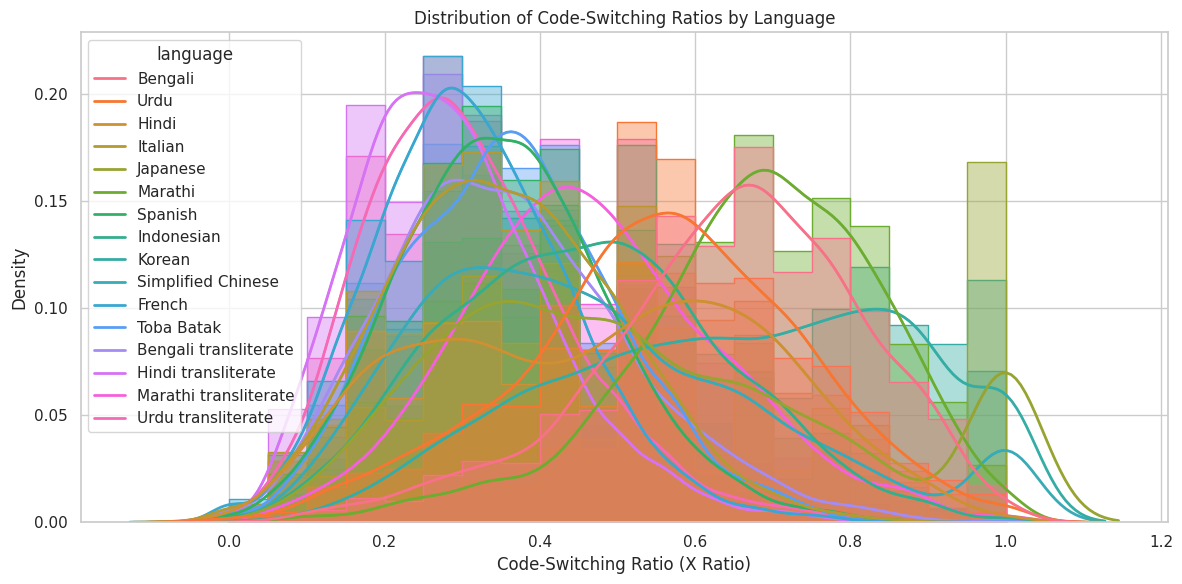

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

ax = sns.histplot(
    data=df,
    x="x_ratio",
    hue="language",
    bins=20,
    kde=True,
    element="step",
    stat="density",
    alpha=0.4  # reduce fill intensity
)

plt.title("Distribution of Code-Switching Ratios by Language")
plt.xlabel("Code-Switching Ratio (X Ratio)")
plt.ylabel("Density")


ax = sns.kdeplot(
    data=df,
    x="x_ratio",
    hue="language",
    fill=False,
    linewidth=2
)
plt.tight_layout()
plt.show()

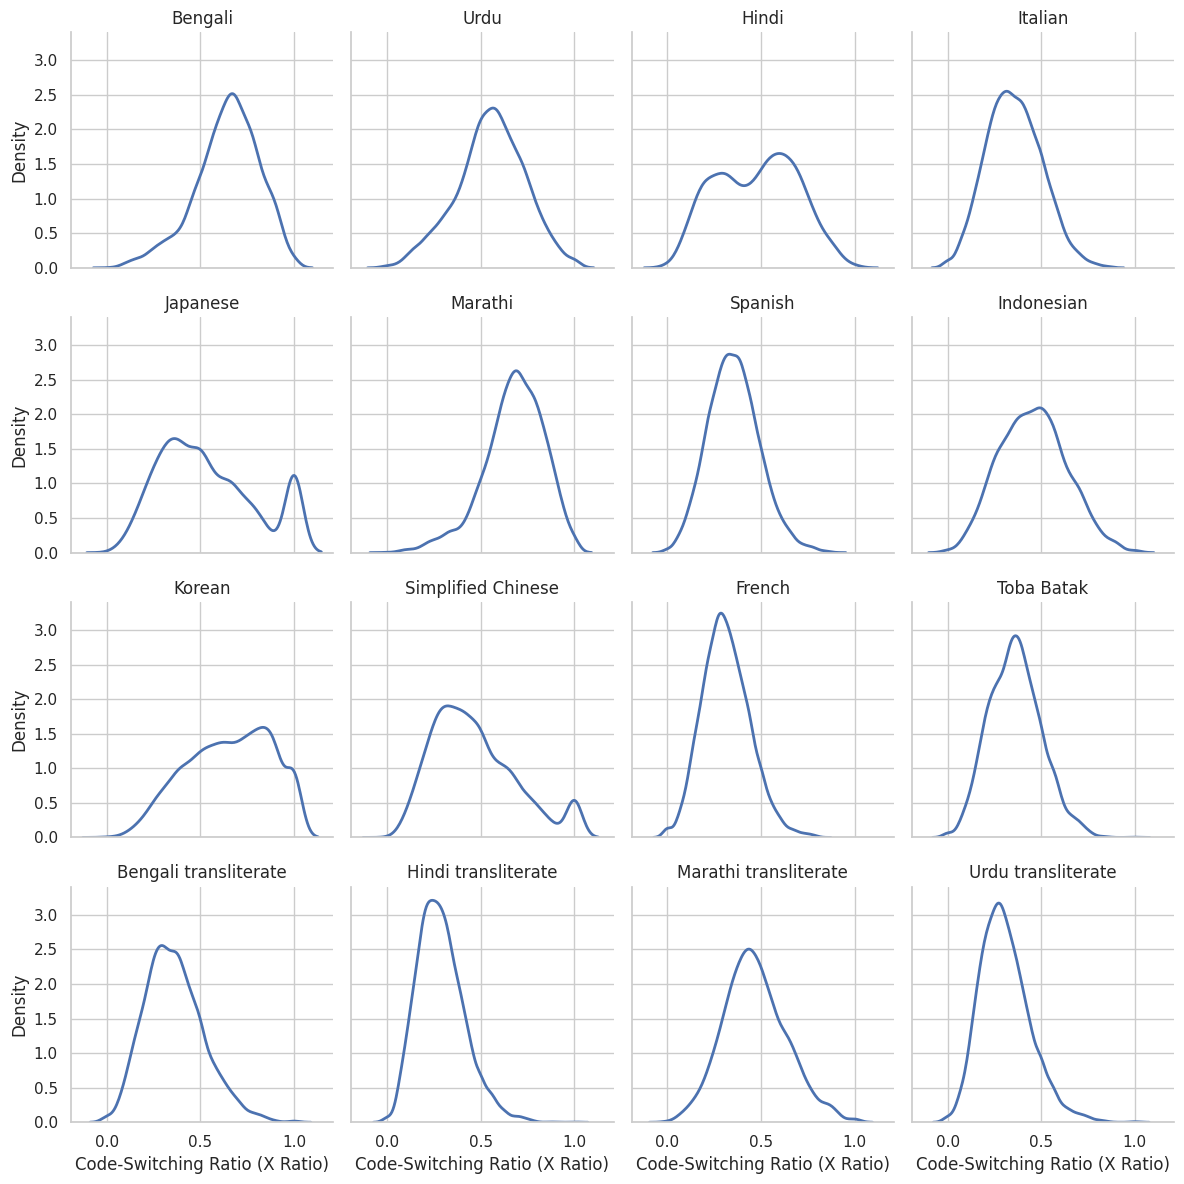

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

g = sns.FacetGrid(
    df,
    col="language",
    col_wrap=4,      # 4 plots per row
    height=3,
    sharex=True,
    sharey=True
)

g.map(sns.kdeplot, "x_ratio", linewidth=2)

g.set_axis_labels("Code-Switching Ratio (X Ratio)", "Density")
g.set_titles("{col_name}")

plt.tight_layout()
plt.show()

/tmp/ipykernel_913142/2573582760.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")


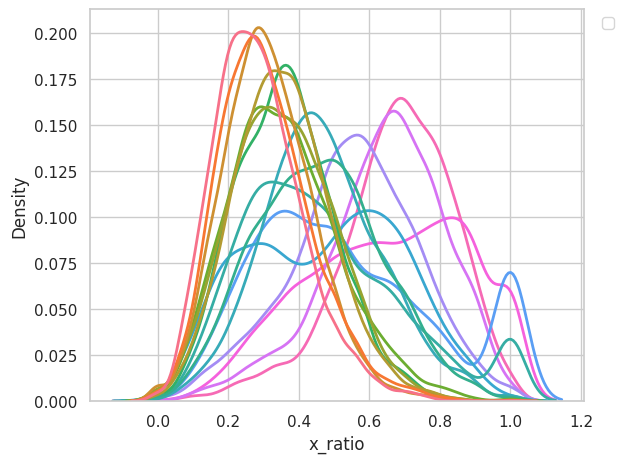

In [ ]:
order = (
    df.groupby("language")["x_ratio"]
    .mean()
    .sort_values()
    .index
)

ax = sns.kdeplot(
    data=df,
    x="x_ratio",
    hue="language",
    hue_order=order,
    linewidth=2
)

plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
df["lang_group"] = df["language"].apply(
    lambda x: "Transliterated" if "transliterate" in x.lower()
    else "Native Script"
)
df_translit = df[df["language"].str.contains("transliterate", case=False)]

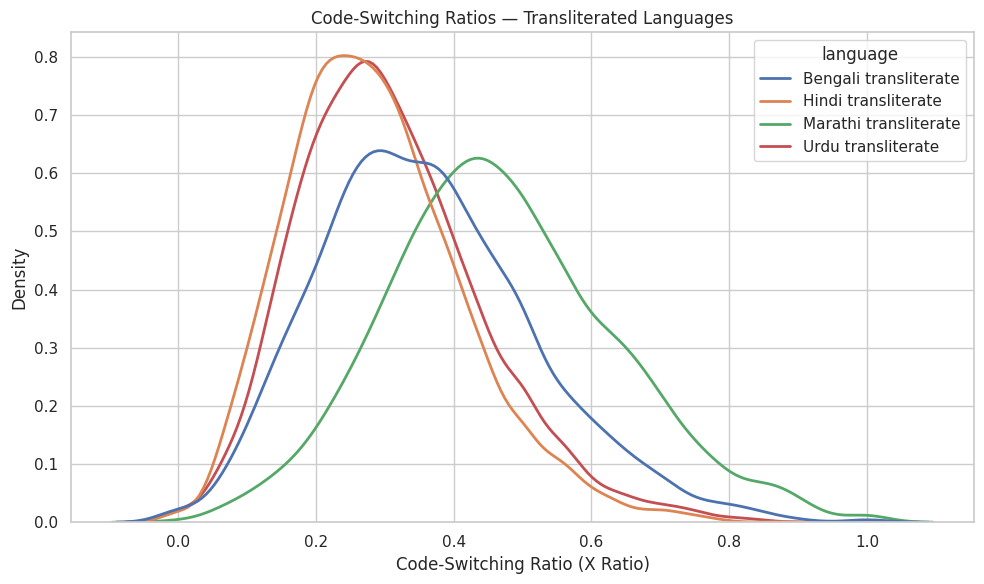

In [ ]:
plt.figure(figsize=(10, 6))

ax = sns.kdeplot(
    data=df_translit,
    x="x_ratio",
    hue="language",
    linewidth=2
)

plt.title("Code-Switching Ratios — Transliterated Languages")
plt.xlabel("Code-Switching Ratio (X Ratio)")
plt.ylabel("Density")

plt.tight_layout()
plt.show()

In [ ]:
df_native = df[df["lang_group"] == "Native Script"]

In [ ]:
df_native

,id,original_index,problem,answer,topic,answer_type,multi_step,requires_reasoning,urls,method,language,x_ratio,ratio_bucket,lang_group
0,2174-grammarforce_source-Bengali,2174,Which baseball field-এ Central Illinois Colleg...,Lloyd Hopkins Field,Sports,Place,False,False,https://www.altonbaseball.com/custom_pages/982...,grammarforce_source,Bengali,0.461538,"(0.4, 0.6]",Native Script
1,2429-grammarforce_target-Urdu,2429,Tivoli Gardens میں Demon کے لیے جگہ بنانے کو ک...,The Snake,Other,Other,False,False,https://sophiessuitcase.com/a-guide-to-tivoli-...,grammarforce_target,Urdu,0.750000,"(0.6, 0.8]",Native Script
2,3532-grammarforce_source-Hindi,3532,1898 में New York के state entomologist की 14t...,Byturus tomentosus,Science and technology,Other,True,False,https://nysl.ptfs.com/aw-server/rest/product/p...,grammarforce_source,Hindi,0.660000,"(0.6, 0.8]",Native Script
3,1452-selective-Italian,1452,After chi was Bullard Mountain named in the Bo...,Benjamin Bullard,Geography,Person,False,False,https://en.wikipedia.org/wiki/Bullard_Mountain...,selective,Italian,0.083333,"(0.0, 0.2]",Native Script
4,4184-force-Japanese,4184,What four 健康組織 wrote to President ジョン・F・ケネディ c...,"American Cancer Society, the American Public H...",History,Other,False,False,https://www.ajmc.com/view/surgeon-generals-smo...,random,Japanese,0.333333,"(0.2, 0.4]",Native Script
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47995,4283-selective-Toba Batak,4283,"Di bulan dohot taon piga Christian Gyrling, te...",November 2023,Video games,Date,False,False,"https://en.wikipedia.org/wiki/Naughty_Dog,http...",selective,Toba Batak,0.500000,"(0.4, 0.6]",Native Script
47996,4287-selective-Toba Batak,4287,Which English singer do na jadi kritikus film ...,George Melly,Music,Person,False,False,https://tv.apple.com/us/person/george-melly/um...,selective,Toba Batak,0.333333,"(0.2, 0.4]",Native Script
47997,4291-selective-Toba Batak,4291,"Ise do na parjolo boru DG di MI5, jala na parj...",Stella Rimington,Politics,Person,False,False,https://www.horus-security.co.uk/articles/nota...,selective,Toba Batak,0.500000,"(0.4, 0.6]",Native Script
47998,4306-selective-Toba Batak,4306,Aha do amana ni William Holwell Carr do for a ...,Apothecary,Art,Other,False,False,https://en.wikipedia.org/wiki/William_Holwell_...,selective,Toba Batak,0.181818,"(0.0, 0.2]",Native Script


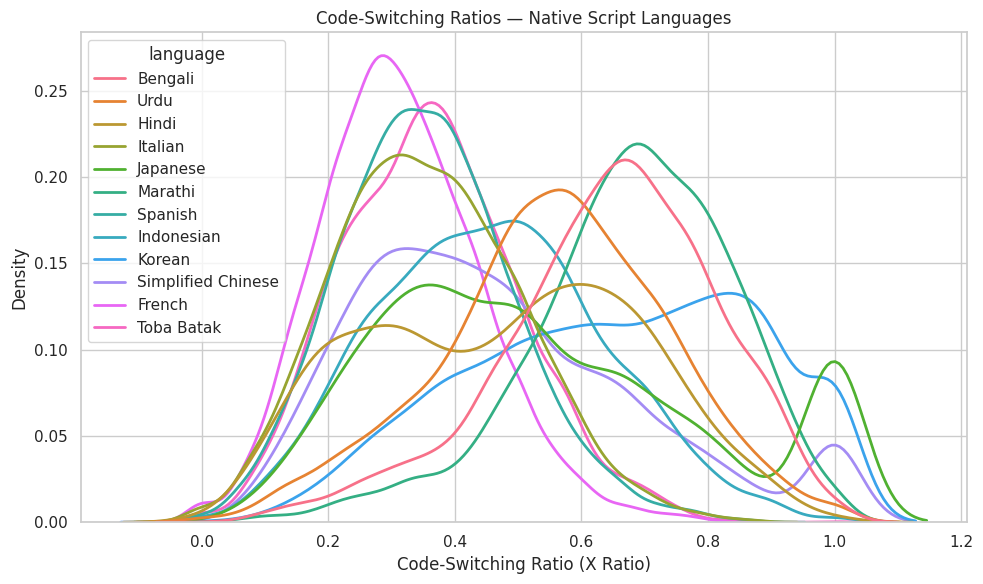

In [ ]:
plt.figure(figsize=(10, 6))

ax = sns.kdeplot(
    data=df_native,
    x="x_ratio",
    hue="language",
    linewidth=2
)

plt.title("Code-Switching Ratios — Native Script Languages")
plt.xlabel("Code-Switching Ratio (X Ratio)")
plt.ylabel("Density")

plt.tight_layout()
plt.show()

In [ ]:
roman_langs = [
    "Italian",
    "Spanish",
    "French",
    "Indonesian"]

df_roman = df[df["language"].isin(roman_langs)]

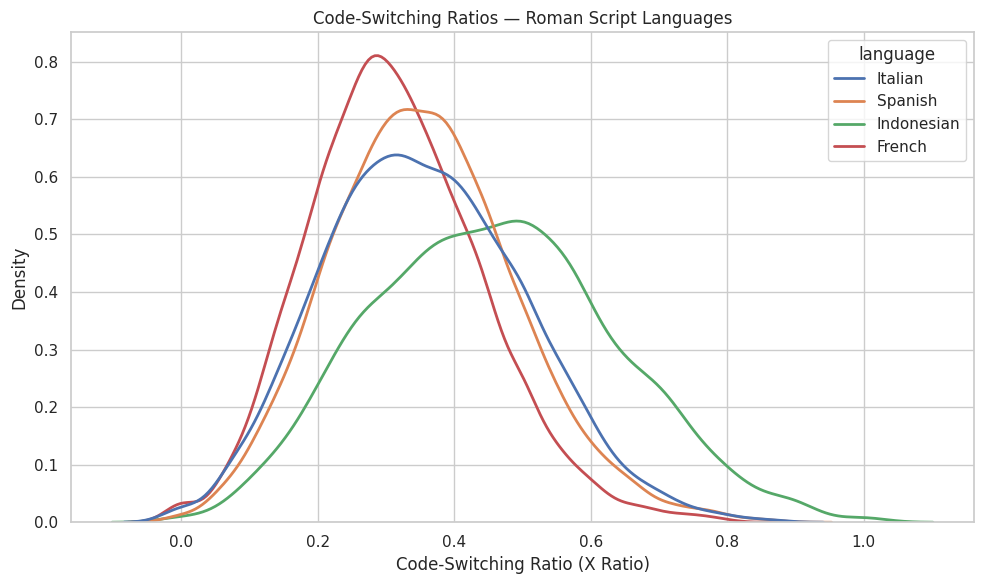

In [ ]:
plt.figure(figsize=(10, 6))

ax = sns.kdeplot(
    data=df_roman,
    x="x_ratio",
    hue="language",
    linewidth=2
)

plt.title("Code-Switching Ratios — Roman Script Languages")
plt.xlabel("Code-Switching Ratio (X Ratio)")
plt.ylabel("Density")

plt.tight_layout()
plt.show()

In [ ]:
roman_langs = [
    "Italian",
    "Spanish",
    "French",
    "Indonesian"]

df_non_roman = df_native[~df_native["language"].isin(roman_langs)]

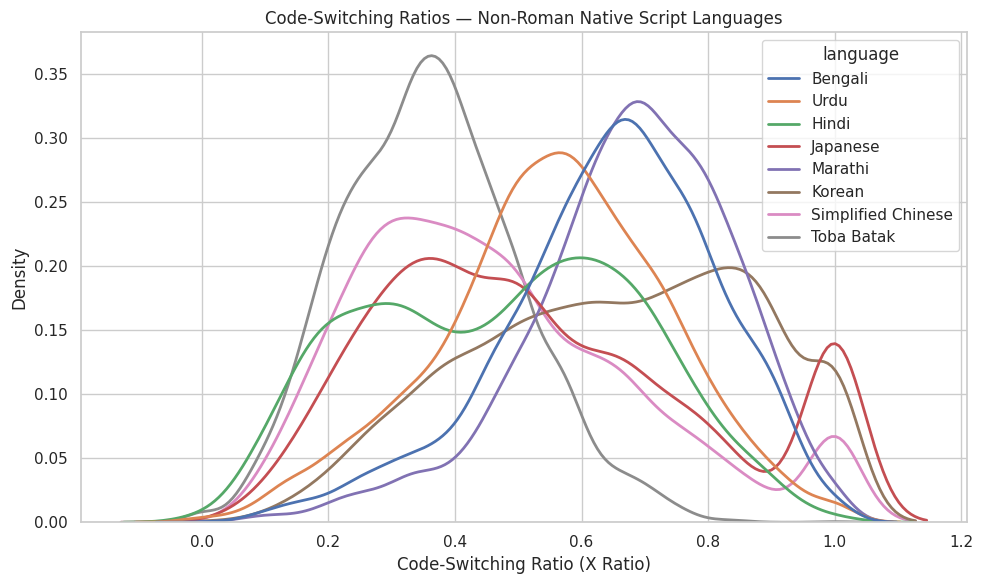

In [ ]:
plt.figure(figsize=(10, 6))

ax = sns.kdeplot(
    data=df_non_roman,
    x="x_ratio",
    hue="language",
    linewidth=2
)

plt.title("Code-Switching Ratios — Non-Roman Native Script Languages")
plt.xlabel("Code-Switching Ratio (X Ratio)")
plt.ylabel("Density")

plt.tight_layout()
plt.show()

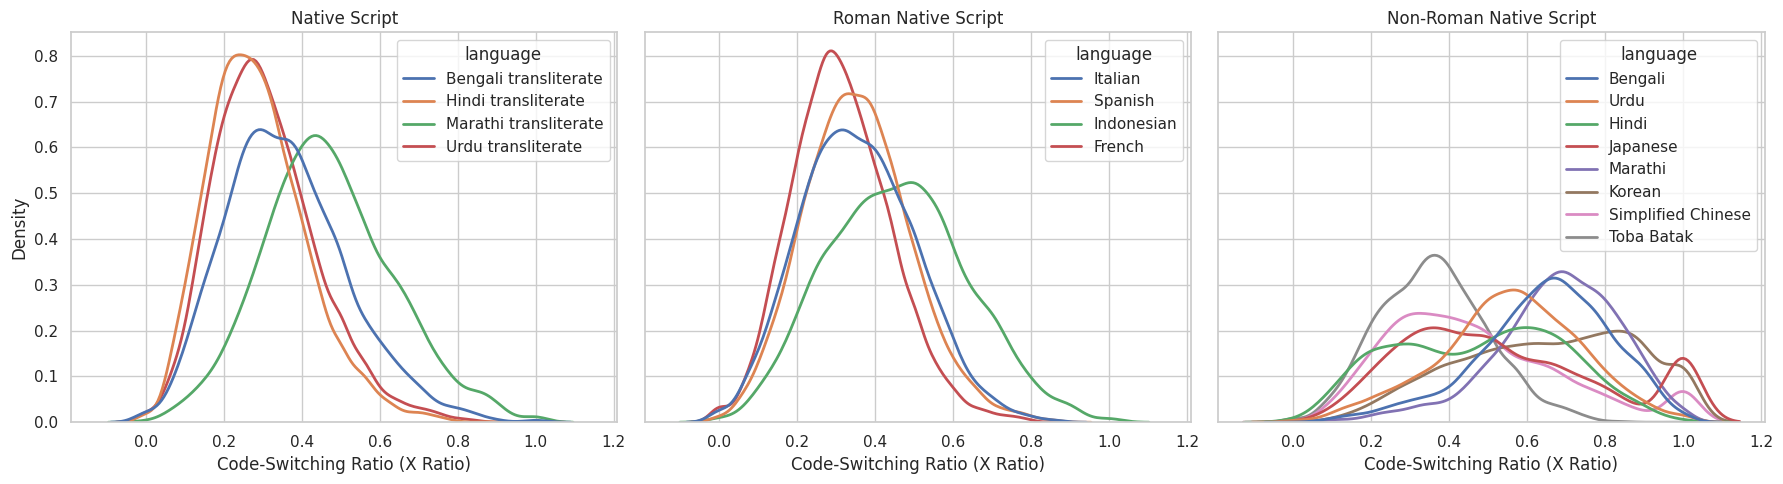

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

# Native
sns.kdeplot(
    data=df_translit,
    x="x_ratio",
    hue="language",
    linewidth=2,
    ax=axes[0]
)
axes[0].set_title("Native Script")

# Roman
sns.kdeplot(
    data=df_roman,
    x="x_ratio",
    hue="language",
    linewidth=2,
    ax=axes[1]
)
axes[1].set_title("Roman Native Script")

# Non-Roman
sns.kdeplot(
    data=df_non_roman,
    x="x_ratio",
    hue="language",
    linewidth=2,
    ax=axes[2]
)
axes[2].set_title("Non-Roman Native Script")

for ax in axes:
    ax.set_xlabel("Code-Switching Ratio (X Ratio)")
    ax.set_ylabel("Density")

plt.tight_layout()
plt.show()